# LushProtein Customer EDA


### 1. Setup & PII Masking


In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RAW_PATH    = '../Data/Customer_data_raw/customers_export_20260622.csv'
MASKED_PATH = '../Data/customers_masked.csv'

In [75]:
import os

PII_COLS = [
    'First Name', 'Last Name', 'Email',
    'Default Address Company',
    'Default Address Address1', 'Default Address Address2',
    'Default Address City', 'Default Address Province Code',
    'Default Address Country Code', 'Default Address Zip',
    'Default Address Phone', 'Phone',
]
# Note: 'Accepts Email Marketing', 'Accepts SMS Marketing', 'Accepts WhatsApp Marketing'
# are kept as original yes/no values — not masked.

raw = pd.read_csv(RAW_PATH)
for col in PII_COLS:
    if col in raw.columns:
        raw[col] = raw[col].notna().astype(int)
raw.to_csv(MASKED_PATH, index=False)
print(f'Masked file created: {MASKED_PATH}')

Masked file created: ../Data/customers_masked.csv


### 2. Load Masked Data


In [76]:
df = pd.read_csv(MASKED_PATH)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.dtypes

Shape: 20,356 rows x 21 columns


Customer ID                       object
First Name                         int64
Last Name                          int64
Email                              int64
Accepts Email Marketing           object
Default Address Company            int64
Default Address Address1           int64
Default Address Address2           int64
Default Address City               int64
Default Address Province Code      int64
Default Address Country Code       int64
Default Address Zip                int64
Default Address Phone              int64
Phone                              int64
Accepts SMS Marketing             object
Total Spent                      float64
Total Orders                       int64
Note                              object
Tax Exempt                        object
Tags                              object
Accepts WhatsApp Marketing        object
dtype: object

In [77]:
# Null counts and fill rates
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'fill_rate_%': (df.notna().sum() / len(df) * 100).round(1)
})
null_summary[null_summary['null_count'] > 0].sort_values('fill_rate_%')

,null_count,fill_rate_%
Note,17985,11.6
Tags,7,100.0


### 3. EDA


#### 3.1 Marketing Consent


In [80]:
consent_cols = ['Accepts Email Marketing', 'Accepts SMS Marketing', 'Accepts WhatsApp Marketing']

consent_rates = {}
for col in consent_cols:
    vc = df[col].value_counts(normalize=True) * 100
    consent_rates[col] = vc

for col in consent_cols:
    print(f'\n{col}:')
    print(df[col].value_counts())


Accepts Email Marketing:
Accepts Email Marketing
yes    11285
no      9071
Name: count, dtype: int64

Accepts SMS Marketing:
Accepts SMS Marketing
no     20138
yes      218
Name: count, dtype: int64

Accepts WhatsApp Marketing:
Accepts WhatsApp Marketing
no    20356
Name: count, dtype: int64


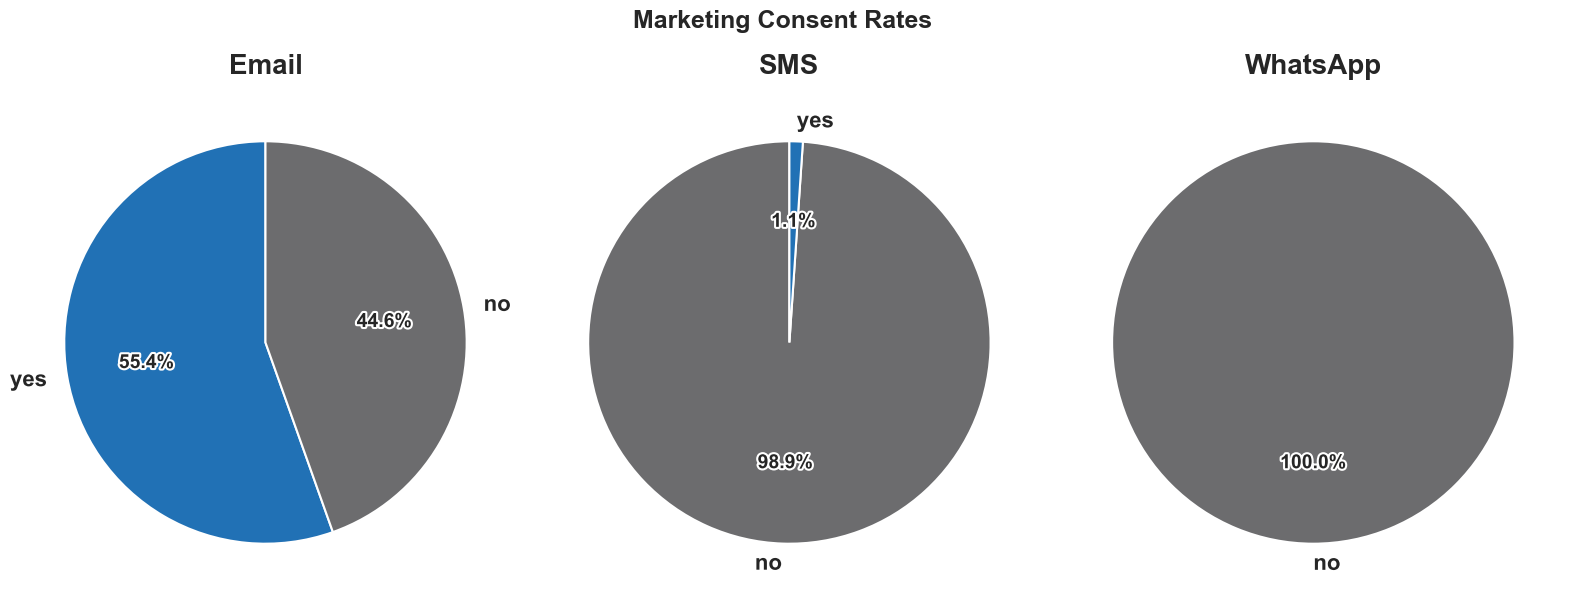

In [81]:
from matplotlib.patheffects import withStroke

COLOR_MAP = {'yes': '#2171b5', 'no': '#6C6C6E'}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, col in zip(axes, consent_cols):
    counts = df[col].value_counts()
    colors = [COLOR_MAP.get(str(k).lower(), "#ffffff") for k in counts.index]
    wedges, texts, autotexts = ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
    )
    outline = [withStroke(linewidth=3, foreground='white')]
    for t in texts:
        t.set_fontsize(16)
        t.set_fontweight('bold')
        t.set_path_effects(outline)
    for at in autotexts:
        at.set_fontsize(14)
        at.set_fontweight('bold')
        at.set_path_effects(outline)
    ax.set_title(
        col.replace('Accepts ', '').replace(' Marketing', ''),
        fontsize=20, fontweight='bold', pad=12
    )

plt.suptitle('Marketing Consent Rates', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 3.2 Spending & Orders Distribution


In [82]:
print('Total Spent:')
print(df['Total Spent'].describe().round(2))
print('\nTotal Orders:')
print(df['Total Orders'].describe().round(2))

Total Spent:
count     20356.00
mean        439.59
std        1743.53
min           1.92
25%          63.90
50%         134.00
75%         316.82
max      114240.00
Name: Total Spent, dtype: float64

Total Orders:
count    20356.00
mean         2.23
std          7.75
min          1.00
25%          1.00
50%          1.00
75%          2.00
max       1014.00
Name: Total Orders, dtype: float64


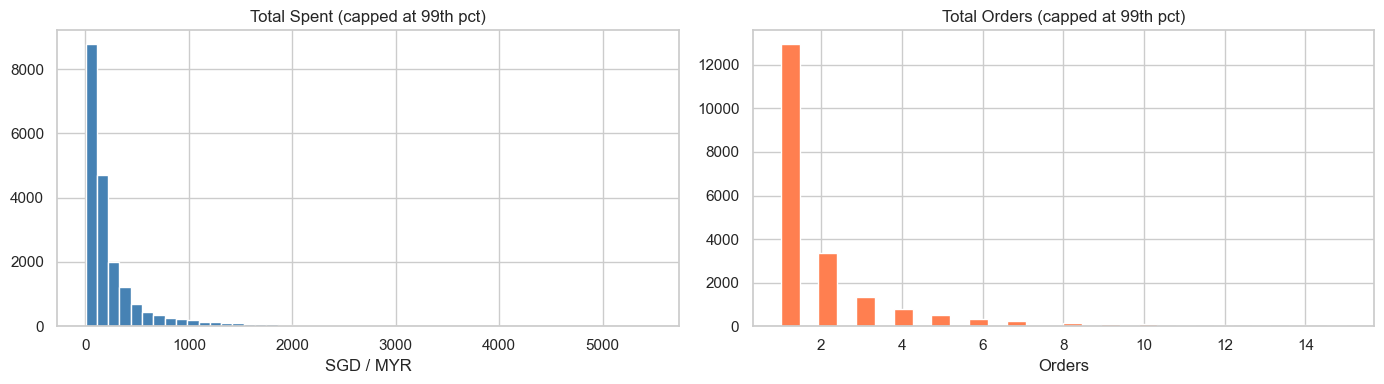

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Cap at 99th percentile to reduce skew from outliers
spent_cap = df['Total Spent'].quantile(0.99)
orders_cap = df['Total Orders'].quantile(0.99)

axes[0].hist(df[df['Total Spent'] <= spent_cap]['Total Spent'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Total Spent (capped at 99th pct)')
axes[0].set_xlabel('SGD / MYR')

axes[1].hist(df[df['Total Orders'] <= orders_cap]['Total Orders'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Total Orders (capped at 99th pct)')
axes[1].set_xlabel('Orders')

plt.tight_layout()
plt.show()

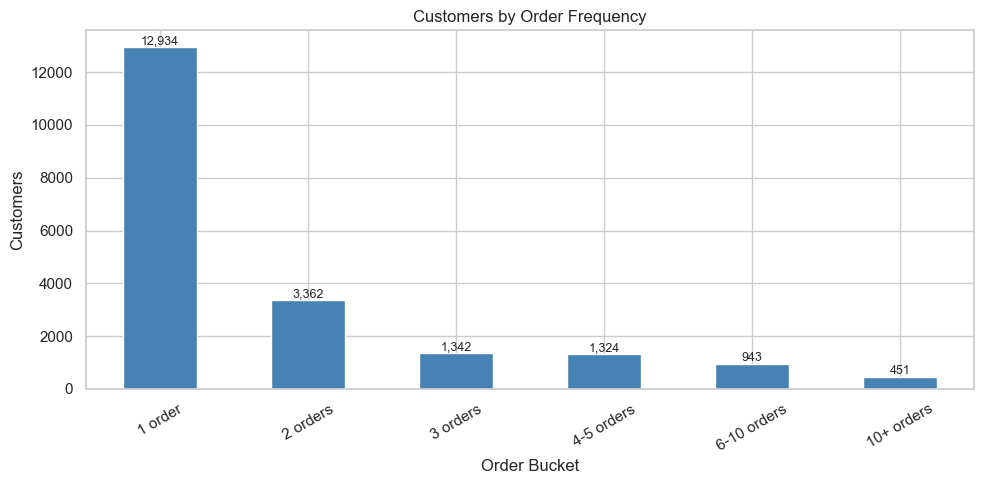

In [84]:
# Order frequency buckets
bins = [0, 1, 2, 3, 5, 10, np.inf]
labels = ['1 order', '2 orders', '3 orders', '4-5 orders', '6-10 orders', '10+ orders']
df['order_bucket'] = pd.cut(df['Total Orders'], bins=bins, labels=labels, right=True)
bucket_counts = df['order_bucket'].value_counts().sort_index()

ax = bucket_counts.plot(kind='bar', color='steelblue', edgecolor='white')
ax.set_title('Customers by Order Frequency')
ax.set_xlabel('Order Bucket')
ax.set_ylabel('Customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### 3.3 Geographic & Gender Distribution

In [85]:
# Load raw just for geographic columns (non-PII: country/province codes)
raw_geo = pd.read_csv(RAW_PATH, usecols=[
    'Customer ID',
    'Default Address Province Code',
    'Default Address Country Code'
])

print('Country distribution:')
print(raw_geo['Default Address Country Code'].value_counts().head(15))

Country distribution:
Default Address Country Code
MY    10193
SG     8402
HK      217
ID      133
AU       33
BN       13
JP       11
VN       10
TW        7
PH        6
US        3
CN        3
TH        3
NZ        2
IN        2
Name: count, dtype: int64


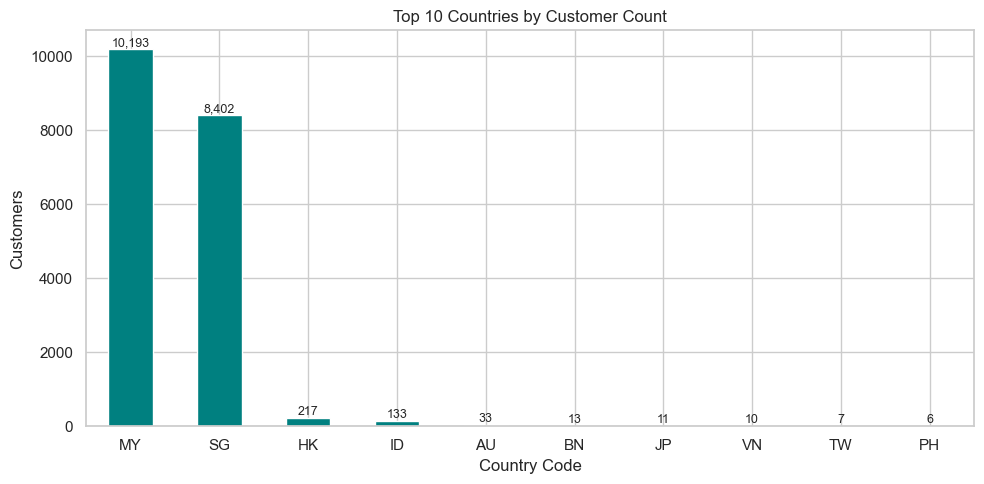

In [86]:
country_counts = raw_geo['Default Address Country Code'].value_counts().head(10)
ax = country_counts.plot(kind='bar', color='teal', edgecolor='white')
ax.set_title('Top 10 Countries by Customer Count')
ax.set_xlabel('Country Code')
ax.set_ylabel('Customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [87]:
GENDER_TAGS = {'male', 'female', 'gender_null'}

def extract_gender(tag_str):
    if pd.isna(tag_str):
        return 'Unknown'
    for tag in [t.strip() for t in tag_str.split(',')]:
        if tag in GENDER_TAGS:
            return tag
    return 'Unknown'

raw_gender = pd.read_csv(RAW_PATH, usecols=['Customer ID', 'Tags'])
raw_gender['gender'] = raw_gender['Tags'].apply(extract_gender)

gender_counts = raw_gender['gender'].value_counts()
print(gender_counts)
print(f"\nTagged with gender : {(raw_gender['gender'] != 'Unknown').sum():,} ({(raw_gender['gender'] != 'Unknown').mean():.1%})")
print(f"No gender tag      : {(raw_gender['gender'] == 'Unknown').sum():,}")

gender
male           8698
female         5837
Unknown        4723
gender_null    1098
Name: count, dtype: int64

Tagged with gender : 15,633 (76.8%)
No gender tag      : 4,723


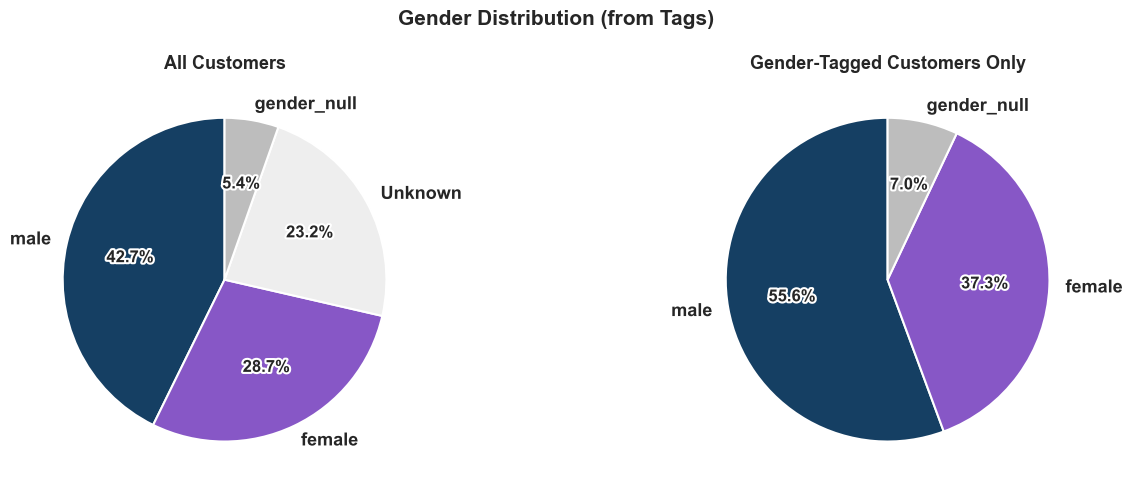

In [98]:
GENDER_COLORS = {'male': "#153F63", 'female': "#8757c6", 'gender_null': '#bdbdbd', 'Unknown': '#eeeeee'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gender Distribution (from Tags)', fontsize=15, fontweight='bold')

outline = [withStroke(linewidth=3, foreground='white')]

# All customers
ax = axes[0]
counts_all = raw_gender['gender'].value_counts()
colors_all = [GENDER_COLORS[k] for k in counts_all.index]
wedges, texts, autotexts = ax.pie(
    counts_all, labels=counts_all.index, autopct='%1.1f%%',
    startangle=90, colors=colors_all, wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)
for t in texts:
    t.set_fontsize(13); t.set_fontweight('bold'); t.set_path_effects(outline)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_path_effects(outline)
ax.set_title('All Customers', fontsize=13, fontweight='bold')

# Tagged only (exclude Unknown)
ax = axes[1]
counts_tagged = raw_gender[raw_gender['gender'] != 'Unknown']['gender'].value_counts()
colors_tagged = [GENDER_COLORS[k] for k in counts_tagged.index]
wedges, texts, autotexts = ax.pie(
    counts_tagged, labels=counts_tagged.index, autopct='%1.1f%%',
    startangle=90, colors=colors_tagged, wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)
for t in texts:
    t.set_fontsize(13); t.set_fontweight('bold'); t.set_path_effects(outline)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_path_effects(outline)
ax.set_title('Gender-Tagged Customers Only', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.4 Tags Analysis


In [89]:
raw_tags = pd.read_csv(RAW_PATH, usecols=['Customer ID', 'Tags'])

all_tags = (
    raw_tags['Tags']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

# Separate ZOKO conflict tags from meaningful tags
zoko_tags  = all_tags[all_tags.str.startswith('ZOKO_')]
clean_tags = all_tags[~all_tags.str.startswith('ZOKO_')]

print(f'Total tag instances: {len(all_tags):,}')
print(f'ZOKO conflict tags:  {len(zoko_tags):,}')
print(f'Meaningful tags:     {len(clean_tags):,}')
print(f'Customers with any ZOKO tag: {raw_tags[raw_tags["Tags"].str.contains("ZOKO_", na=False)].shape[0]:,}')

Total tag instances: 82,361
ZOKO conflict tags:  4,345
Meaningful tags:     78,016
Customers with any ZOKO tag: 2,033


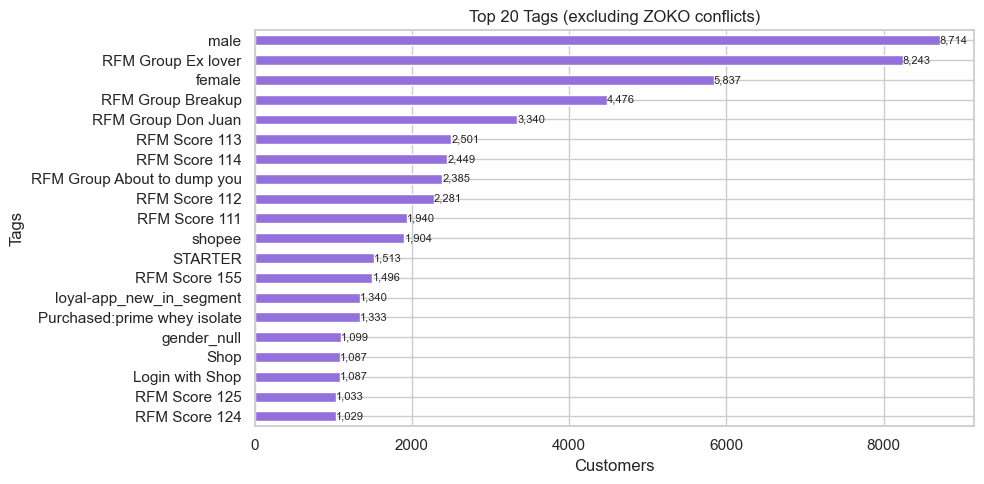

In [90]:
# Top meaningful tags
top_tags = clean_tags.value_counts().head(20)
ax = top_tags.sort_values().plot(kind='barh', color='mediumpurple', edgecolor='white')
ax.set_title('Top 20 Tags (excluding ZOKO conflicts)')
ax.set_xlabel('Customers')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [91]:
# Tag category breakdown
def categorise_tag(tag):
    t = str(tag)
    if t.startswith('RFM Score'):   return 'RFM Score'
    if t.startswith('RFM Group'):   return 'RFM Group'
    if t.startswith('EVENT_'):      return 'Event'
    if t.startswith('HYROX'):       return 'Event'
    if t.startswith('prq_quiz_'):   return 'Quiz (PRQ)'
    if t.startswith('quiz_'):       return 'Quiz'
    if t.startswith('loyal-app_'):  return 'Loyalty App'
    if t in ('Active Subscriber', 'Inactive Subscriber', 'Inactive product subscriber'): return 'Subscriber Status'
    if t in ('Has active product subscriptions', 'Yotpo Subscriptions',
              'Subscription card declined', 'recharge_tags_restored'): return 'Subscription'
    if t in ('male', 'female', 'gender_null'): return 'Gender'
    if t in ('Amazon', 'Lazada', 'shopee', 'tiktok', 'Shop', 'affiliate',
              'wholesale-buyer', 'Referral', 'Login with Shop', 'Inbox Shop Chat',
              'Inbox online store chat'): return 'Channel/Source'
    if t.startswith('WELCOME') or t in ('FLOWTRIGGER', 'FLOWTRIGGER2',
              'STARTER', 'STARTER_LEAN', 'newsletter', 'FIRST_ORDER_POS'): return 'Marketing Flow'
    if t.startswith('ZOKO_'):       return 'ZOKO Conflict'
    return 'Other'

tag_cats = all_tags.apply(categorise_tag).value_counts()
print(tag_cats)

Tags
RFM Group            20306
RFM Score            20306
Gender               15650
Channel/Source        5496
ZOKO Conflict         4345
Quiz                  3685
Loyalty App           3075
Other                 2726
Marketing Flow        2632
Quiz (PRQ)            1744
Subscriber Status     1124
Subscription           909
Event                  363
Name: count, dtype: int64


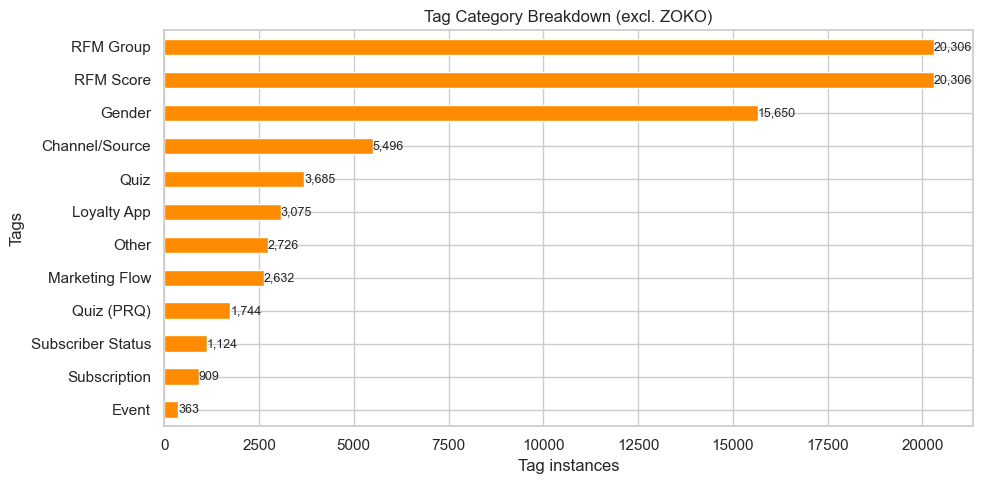

In [92]:
tag_cats_clean = tag_cats.drop('ZOKO Conflict', errors='ignore')
ax = tag_cats_clean.sort_values().plot(kind='barh', color='darkorange', edgecolor='white')
ax.set_title('Tag Category Breakdown (excl. ZOKO)')
ax.set_xlabel('Tag instances')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### 3.5 RFM Group Snapshot


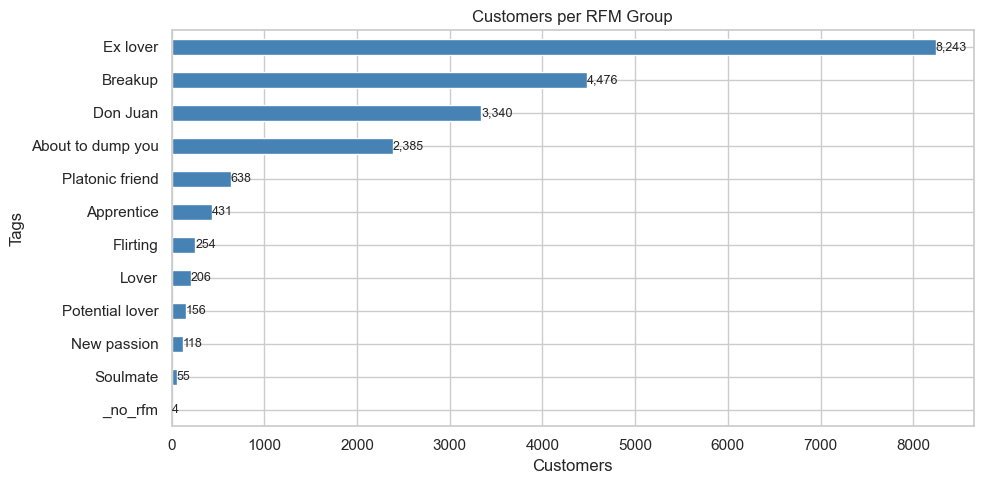

In [93]:
rfm_group_tags = clean_tags[clean_tags.str.startswith('RFM Group')]
rfm_counts = rfm_group_tags.value_counts()

ax = rfm_counts.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
ax.set_title('Customers per RFM Group')
ax.set_xlabel('Customers')
ax.set_yticklabels([l.replace('RFM Group ', '') for l in rfm_counts.sort_values().index])
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### 3.6 Spending by Subscriber Status


In [94]:
# Tag each customer with their subscriber status
sub_status_map = {
    'Active Subscriber': 'Active Subscriber',
    'Inactive Subscriber': 'Inactive Subscriber',
    'Inactive product subscriber': 'Inactive product subscriber',
}

def get_sub_status(tag_str):
    if pd.isna(tag_str):
        return 'No Tag'
    for key in sub_status_map:
        if key in tag_str:
            return key
    return 'No Sub Tag'

raw_spend = pd.read_csv(RAW_PATH, usecols=['Customer ID', 'Tags', 'Total Spent', 'Total Orders'])
raw_spend['sub_status'] = raw_spend['Tags'].apply(get_sub_status)

spend_by_status = raw_spend.groupby('sub_status')['Total Spent'].agg(['mean', 'median', 'count']).round(2)
print(spend_by_status.sort_values('median', ascending=False))

                                mean  median  count
sub_status                                         
Inactive product subscriber  1107.93  340.20    335
Active Subscriber             882.53  240.71    262
Inactive Subscriber           909.83  177.29    492
No Sub Tag                    410.06  130.00  19260
No Tag                         72.32   65.86      7


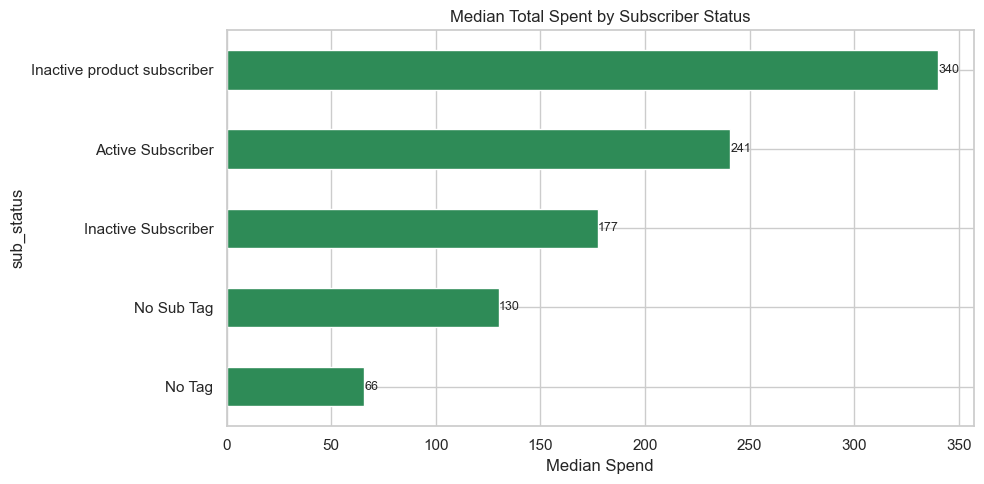

In [95]:
ax = spend_by_status['median'].sort_values().plot(kind='barh', color='seagreen', edgecolor='white')
ax.set_title('Median Total Spent by Subscriber Status')
ax.set_xlabel('Median Spend')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 4 Decile Membership Check — Which Customers Are in the Decile Pool?

In [96]:
from pathlib import Path

FINALS_DIR = Path('outputs_finals')

# Shopify export prepends ' to IDs to prevent Excel from using scientific notation — strip it
def normalise_id(s):
    return s.astype(str).str.strip().str.lstrip("'").str.replace(r'\.0$', '', regex=True)

# Load IDs from each source
export_ids    = normalise_id(pd.read_csv(RAW_PATH, usecols=['Customer ID'])['Customer ID'])
decile_ids    = normalise_id(pd.read_csv(FINALS_DIR / 'decile_customer_table.csv',  usecols=['customer_id'])['customer_id'])
timebased_ids = normalise_id(pd.read_csv(FINALS_DIR / 'decile_timebased_table.csv', usecols=['customer_id'])['customer_id'])

in_decile     = set(export_ids) & set(decile_ids)
in_timebased  = set(export_ids) & set(timebased_ids)
not_in_decile = set(export_ids) - set(decile_ids)

print(f"Customer export         : {len(export_ids):,}")
print(f"In decile pool          : {len(in_decile):,} ({len(in_decile)/len(export_ids):.1%})")
print(f"With activity status    : {len(in_timebased):,} ({len(in_timebased)/len(export_ids):.1%})")
print(f"Not in decile pool      : {len(not_in_decile):,} ({len(not_in_decile)/len(export_ids):.1%})")

Customer export         : 20,356
In decile pool          : 4,290 (21.1%)
With activity status    : 4,290 (21.1%)
Not in decile pool      : 16,066 (78.9%)


In [97]:
# Diagnose ID format before comparing
export_ids_raw = pd.read_csv(RAW_PATH, usecols=['Customer ID'])['Customer ID']
decile_ids_raw = pd.read_csv(FINALS_DIR / 'decile_customer_table.csv', usecols=['customer_id'])['customer_id']

print("=== ID FORMAT DIAGNOSIS ===")
print(f"\nExport dtype  : {export_ids_raw.dtype}")
print(f"Decile dtype  : {decile_ids_raw.dtype}")
print(f"\nExport sample IDs:")
print(export_ids_raw.head(5).tolist())
print(f"\nDecile sample IDs:")
print(decile_ids_raw.head(5).tolist())

=== ID FORMAT DIAGNOSIS ===

Export dtype  : object
Decile dtype  : int64

Export sample IDs:
["'6327387259135", "'6327387652351", "'6327387750655", "'6327388078335", "'6327388111103"]

Decile sample IDs:
[7756044599551, 7756032868607, 8712766128383, 7964005826815, 7958758916351]
